<h1>Train — EfficientNet-B0</h1>

Trains and evaluates EfficientNet-B0 using the tuned hyperparameters from `ARCH_HYPERPARAMS["efficientnet_b0"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): CapeFlats
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 785 | Val: 192 | Test: 766


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["efficientnet_b0"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"EfficientNet-B0: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

EfficientNet-B0: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with EfficientNet-B0)
# ---------------------------------------------------------
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# EfficientNet's classifier is nn.Sequential(Dropout, Linear) — swap out
# just the Linear layer for our (optionally deeper) classifier head, same
# as the fc/classifier swaps used for the other architectures.
in_f = model.classifier[1].in_features
model.classifier[1] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[EfficientNet-B0] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[EfficientNet-B0] Epoch   1/100 | LR: 1.38e-03 | train loss 1.1303 acc 0.504 | val loss 0.9624 acc 0.594 *


[EfficientNet-B0] Epoch   2/100 | LR: 1.38e-03 | train loss 0.9493 acc 0.610 | val loss 0.6595 acc 0.724 *


[EfficientNet-B0] Epoch   3/100 | LR: 1.38e-03 | train loss 0.8193 acc 0.702 | val loss 0.8655 acc 0.531


[EfficientNet-B0] Epoch   4/100 | LR: 1.38e-03 | train loss 0.8800 acc 0.659 | val loss 0.8659 acc 0.583


...

[EfficientNet-B0] Epoch  40/100 | LR: 1.38e-04 | train loss 0.1190 acc 0.955 | val loss 0.3230 acc 0.875


[EfficientNet-B0] Epoch  41/100 | LR: 1.38e-04 | train loss 0.1032 acc 0.966 | val loss 0.3500 acc 0.880


[EfficientNet-B0] Epoch  42/100 | LR: 1.38e-04 | train loss 0.1253 acc 0.954 | val loss 0.3660 acc 0.875


[EfficientNet-B0] Epoch  43/100 | LR: 1.38e-04 | train loss 0.1199 acc 0.962 | val loss 0.3521 acc 0.875


[EfficientNet-B0] Epoch  44/100 | LR: 1.38e-04 | train loss 0.0901 acc 0.967 | val loss 0.3911 acc 0.870

[EfficientNet-B0] No val loss improvement for 10 epochs — stopping early at epoch 44.

[EfficientNet-B0] Restored best checkpoint (val loss = 0.2918)


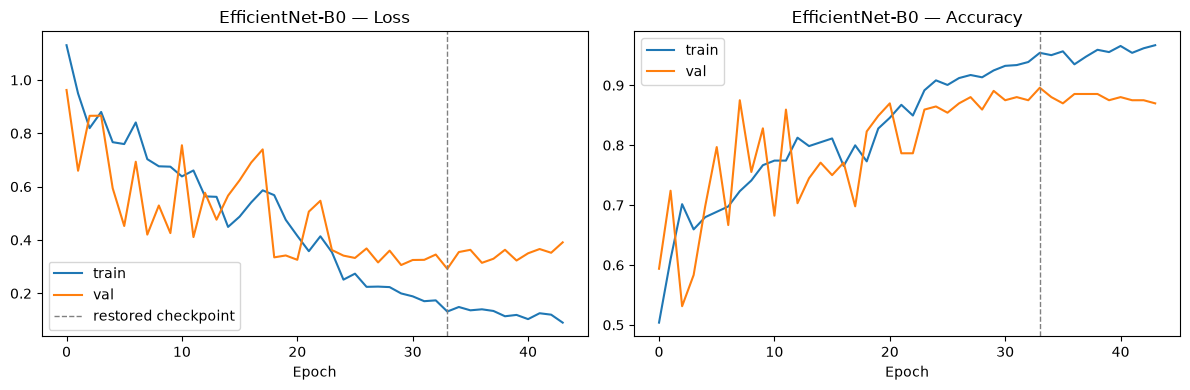

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "EfficientNet-B0", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "EfficientNet-B0")

## Evaluate on the test set

[EfficientNet-B0] Test accuracy: 0.483


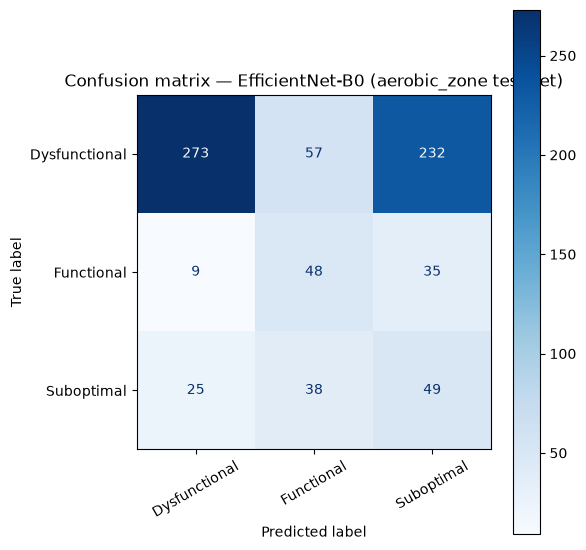

               precision    recall  f1-score   support

Dysfunctional      0.889     0.486     0.628       562
   Functional      0.336     0.522     0.409        92
   Suboptimal      0.155     0.438     0.229       112

     accuracy                          0.483       766
    macro avg      0.460     0.482     0.422       766
 weighted avg      0.715     0.483     0.544       766



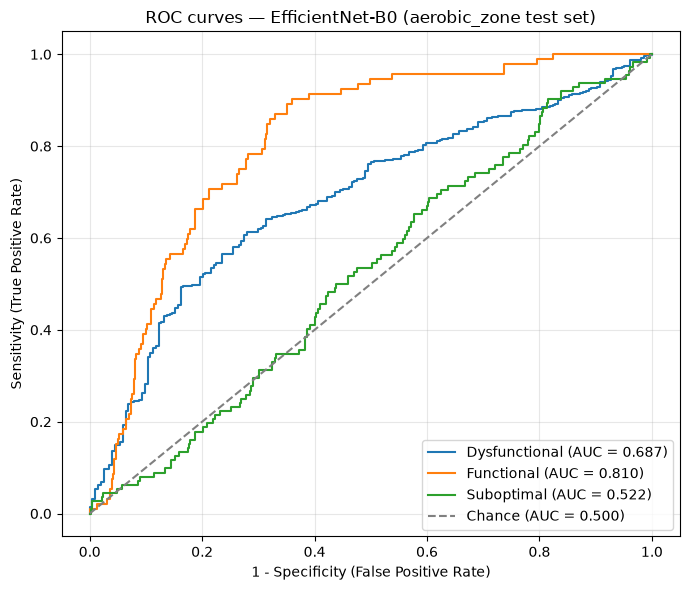

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.687
  Functional     : 0.810
  Suboptimal     : 0.522

Mean AUC (over 3/3 classes with test examples): 0.673


(np.float64(0.4830287206266319),
 {'Dysfunctional': 0.6866931826111227,
  'Functional': 0.8103147980905689,
  'Suboptimal': 0.5215842070773263})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "EfficientNet-B0", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("EfficientNet-B0", "efficientnet_b0")

Saved results to ../results/aerobic_zone_aug/results_aerobic_zone_efficientnet_b0_CapeFlats.pkl


Saved model weights to ../models/aerobic_zone_efficientnet_b0_cnn.pt
